In [1]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

import sys
sys.path.append('/content/drive/MyDrive/crowd_dataset/ShanghaiTech_Crowd_Counting_Dataset')


Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
import scipy.io
from scipy.spatial import KDTree
import tensorflow as tf

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Reshape
from tensorflow.keras.applications import VGG16
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers import Adam

# Check if GPU is detected
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [3]:
BATCH_SIZE = 1
SUBSAMPLING_FACTOR = 8
LR = 1e-5
EPOCH = 50

In [4]:
def gauss_distribution(x, u = 0, sigma = 10):
    return np.expand_dims((1/(np.sqrt(2*np.pi*(sigma**2)))) * np.exp(-(0.5) * (((x-u) / sigma)**2)), axis = 0)

# input - image, output - image
def pad_to_multiple(image, factor=32):
    h, w = image.shape[:2]

    # Calculate how many pixels to add
    pad_h = (factor - (h % factor)) % factor
    pad_w = (factor - (w % factor)) % factor

    # Apply padding to the bottom and right only
    # (top, bottom, left, right)
    padded_img = cv2.copyMakeBorder(image, 0, pad_h, 0, pad_w,
                                    cv2.BORDER_CONSTANT, value=0)

    return padded_img

def get_rand(min_val, max_val):
    """Generates a random integer using TensorFlow"""
    return tf.random.uniform((1,), minval=min_val, maxval=max_val, dtype=tf.int32)[0].numpy()

# input - (height , width), output - 9 patch values for each (image, density map)
def get_patches(IN_H, IN_W):
    """Calculates coordinates for fixed and random image patches"""
    # Fixed quadrants
    patch_1 = np.array([IN_H//8, IN_W//8, 0, 0])
    patch_2 = np.array([IN_H//2, IN_W//8, 0, 0])
    patch_3 = np.array([IN_H//8, IN_W//2, 0, 0])
    patch_4 = np.array([IN_H//2, IN_W//2, 0, 0])

    # Randomly located patches
    patch_5 = np.array([get_rand(0, int(IN_H*0.75)), get_rand(0, int(IN_W*0.75)), 0, 0])
    patch_6 = np.array([get_rand(0, int(IN_H*0.75)), get_rand(0, int(IN_W*0.75)), 0, 0])
    patch_7 = np.array([get_rand(0, int(IN_H*0.75)), get_rand(0, int(IN_W*0.75)), 0, 0])
    patch_8 = np.array([get_rand(0, int(IN_H*0.75)), get_rand(0, int(IN_W*0.75)), 0, 0])
    patch_9 = np.array([get_rand(0, int(IN_H*0.75)), get_rand(0, int(IN_W*0.75)), 0, 0])

    patches = np.array([patch_1, patch_2, patch_3, patch_4, patch_5, patch_6, patch_7, patch_8, patch_9])

    # Calculate patch size (1/4 of dimension)
    for p in patches:
        p[2] = p[0] + IN_H//4
        p[3] = p[1] + IN_W//4

    patches = tf.random.shuffle(patches)
    return patches, patches//SUBSAMPLING_FACTOR

# generates patched image / density map based on input, output - image
def generate_new(patch, IN_H, IN_W, is_image = True):

    if(is_image):
        im_new = np.zeros([IN_H, IN_W, 3])
    else:
        im_new = np.zeros([IN_H, IN_W])

    for i in range(3):

        im_new[0: (0+(IN_H//3)), (i*(IN_W//3)): (i*(IN_W//3)) + (IN_W//3)] = patch[3*i]
        im_new[(IN_H//3): (IN_H//3)+ (IN_H//3), (i*(IN_W//3)): (i*(IN_W//3)) + (IN_W//3)] = patch[3*i + 1]
        im_new[(2*(IN_H//3)): (2*(IN_H//3))+ (IN_H//3), (i*(IN_W//3)): (i*(IN_W//3)) + (IN_W//3)] = patch[3*i + 2]

    return im_new

In [5]:

def get_density_map_gaussian(im, points, subsampling_factor=8, gaussian_radius=None):
    out_h = im.shape[0] // subsampling_factor
    out_w = im.shape[1] // subsampling_factor

    density_map = np.zeros((out_h, out_w), dtype=np.float32)

    if len(points) == 0:
        return density_map

    h, w = out_h, out_w

    # --- ADAPTIVE KERNEL: build KD-tree on downsampled coordinates ---
    # points are already divided by subsampling_factor (in density map space)
    pts = np.array(points, dtype=np.float32)   # shape (N, 2), (x, y) in map space

    if len(pts) >= 4:
        # Build KD-tree on (x, y) positions
        tree = KDTree(pts)
        # For each point, find 3 nearest neighbours (excluding itself)
        distances, _ = tree.query(pts, k=4)     # k=4 → first is self (dist=0), next 3 are neighbours
        avg_distances = np.mean(distances[:, 1:4], axis=1)  # avg of 3 neighbours per point
    else:
        # Too few points for KNN — fall back to fixed sigma
        avg_distances = np.full(len(pts), 15.0 / subsampling_factor)

    for i, point in enumerate(points):
        point = np.round(point).astype(int)
        point[0], point[1] = max(0, min(h-1, point[1])), max(0, min(w-1, point[0]))

        # Sigma = 0.3 * average distance to 3 nearest neighbours (as per CSRNet paper)
        sigma = max(1.0, 0.3 * avg_distances[i])

        # Kernel radius = 3*sigma, clipped to a reasonable max
        gaussian_radius = min(int(3 * sigma), 20)

        x = np.linspace(-gaussian_radius, gaussian_radius, (gaussian_radius * 2) + 1)

        gaussian_map = np.multiply(gauss_distribution(x, sigma=sigma),
                                   gauss_distribution(x, sigma=sigma).T)
        gaussian_map /= np.sum(gaussian_map)

        x_left, x_right = 0, gaussian_map.shape[1]
        y_up,   y_down  = 0, gaussian_map.shape[0]

        if point[1] < gaussian_radius:
            x_left = gaussian_radius - point[1]
        if point[0] < gaussian_radius:
            y_up = gaussian_radius - point[0]
        if point[1] + gaussian_radius >= w:
            x_right = gaussian_map.shape[1] - (gaussian_radius + point[1] - w) - 1
        if point[0] + gaussian_radius >= h:
            y_down = gaussian_map.shape[0] - (gaussian_radius + point[0] - h) - 1

        density_map[
            max(0, point[0]-gaussian_radius):min(density_map.shape[0], point[0]+gaussian_radius+1),
            max(0, point[1]-gaussian_radius):min(density_map.shape[1], point[1]+gaussian_radius+1)
        ] += gaussian_map[y_up:y_down, x_left:x_right]

    return density_map

In [6]:
class DataGenerator(tf.keras.utils.Sequence):

    def __init__(self, images, maps, batch_size=1, SUBSAMPLING_FACTOR=8, **kwargs):
        super().__init__(**kwargs)
        self.images = images
        self.maps = maps
        self.batch_size = batch_size
        self.SUBSAMPLING_FACTOR = SUBSAMPLING_FACTOR

        orig_images = sorted(os.listdir(images))
        orig_maps   = sorted(os.listdir(maps))

        # Double the dataset: original + flipped versions
        self.train_image_list = orig_images + orig_images   # 600 entries
        self.train_map_list   = orig_maps   + orig_maps     # 600 entries
        self.flip_flags       = [False] * len(orig_images) + [True] * len(orig_images)

    def __len__(self):
        return int(np.floor(len(self.train_image_list) / self.batch_size))

    def __getitem__(self, idx):
        X, y = self.__data_generation(idx)
        return X, y

    def __data_generation(self, idx):
        X = []
        y = []

        for j in range(idx * self.batch_size, (idx + 1) * self.batch_size):

            # ── Load and preprocess image ──────────────────────────────
            im_path  = self.images + self.train_image_list[j]
            im_array = img_to_array(load_img(im_path))

            im_array /= 255
            im_array[:,:,0] = (im_array[:,:,0] - np.mean(im_array[:,:,0])) / np.std(im_array[:,:,0])
            im_array[:,:,1] = (im_array[:,:,1] - np.mean(im_array[:,:,1])) / np.std(im_array[:,:,1])
            im_array[:,:,2] = (im_array[:,:,2] - np.mean(im_array[:,:,2])) / np.std(im_array[:,:,2])

            # ── Load raw points ────────────────────────────────────────
            mat_path   = self.maps + self.train_map_list[j]
            mat        = scipy.io.loadmat(mat_path)
            points_raw = mat['image_info'][0][0][0][0][0].copy()  # (N,2) x,y in image space

            # ── Step 1: Flip image and points BEFORE padding ──────────
            if self.flip_flags[j]:
                orig_W           = im_array.shape[1]
                im_array         = np.fliplr(im_array).copy()
                points_raw       = points_raw.copy()
                points_raw[:, 0] = orig_W - 1 - points_raw[:, 0]  # mirror x coords only

            # ── Step 2: Pad AFTER flip (padding always on right/bottom) ─
            padded_img = pad_to_multiple(im_array, factor=32)
            IN_H, IN_W = padded_img.shape[:2]

            # ── Step 3: Scale points to density map space ──────────────
            points  = points_raw.copy()
            points /= self.SUBSAMPLING_FACTOR

            # ── Step 4: Generate density map ───────────────────────────
            density_map_full = get_density_map_gaussian(
                padded_img, points,
                subsampling_factor=self.SUBSAMPLING_FACTOR,
                gaussian_radius=5
            )

            # ── Step 5: Full image (30%) vs patch mosaic (70%) ─────────
            if np.random.rand() < 0.3:

                # Full image — resize to canonical patch-mosaic size
                canonical_H = 3 * (IN_H // 4)
                canonical_W = 3 * (IN_W // 4)
                aug_img = cv2.resize(
                    padded_img,
                    (canonical_W, canonical_H),
                    interpolation=cv2.INTER_LINEAR
                )

                canonical_map_H = 3 * ((IN_H // self.SUBSAMPLING_FACTOR) // 4)
                canonical_map_W = 3 * ((IN_W // self.SUBSAMPLING_FACTOR) // 4)

                orig_sum = np.sum(density_map_full)
                aug_map  = cv2.resize(
                    density_map_full,
                    (canonical_map_W, canonical_map_H),
                    interpolation=cv2.INTER_LINEAR
                )
                # Restore total count after resize
                if np.sum(aug_map) > 0:
                    aug_map = aug_map * (orig_sum / np.sum(aug_map))

            else:

                # Patch mosaic — random 9 patches assembled into 3x3 grid
                p_img, p_map = get_patches(IN_H, IN_W)

                if tf.is_tensor(p_img): p_img = p_img.numpy()
                if tf.is_tensor(p_map): p_map = p_map.numpy()

                img_patches = [padded_img[p[0]:p[2], p[1]:p[3]] for p in p_img]
                map_patches = [density_map_full[mp[0]:mp[2], mp[1]:mp[3]] for mp in p_map]

                target_H     = 3 * (IN_H // 4)
                target_W     = 3 * (IN_W // 4)
                aug_img      = generate_new(img_patches, target_H, target_W, is_image=True)

                target_map_H = 3 * ((IN_H // self.SUBSAMPLING_FACTOR) // 4)
                target_map_W = 3 * ((IN_W // self.SUBSAMPLING_FACTOR) // 4)
                aug_map      = generate_new(map_patches, target_map_H, target_map_W, is_image=False)

            X.append(aug_img)
            y.append(aug_map)

        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [9]:
train_images = '/content/drive/MyDrive/ShanghaiTech_Crowd_Counting_Dataset/part_A_final/train_data/images/'
train_maps = '/content/drive/MyDrive/ShanghaiTech_Crowd_Counting_Dataset/part_A_final/train_data/ground_truth/'


train_gen = DataGenerator(train_images, train_maps, BATCH_SIZE, SUBSAMPLING_FACTOR)



In [10]:
def get_base_model():
    base_model = VGG16(weights='imagenet', input_shape=(None, None, 3), include_top=False)

    # Start fully frozen — will unfreeze in phase 2 of training
    for layer in base_model.layers[:10]:
        layer.trainable = False

    block4_conv3 = base_model.get_layer("block4_conv3").output
    return tf.keras.Model(inputs=base_model.inputs, outputs=block4_conv3)

In [11]:
inputs = tf.keras.Input(shape=(None, None, 3))

x = get_base_model()(inputs) # Removed [0] to keep the batch dimension

init = RandomNormal(stddev=0.01)

x = Conv2D(512, (3, 3), activation='relu', dilation_rate=2, kernel_initializer=init, padding='same')(x)
x = Conv2D(512, (3, 3), activation='relu', dilation_rate=2, kernel_initializer=init, padding='same')(x)
x = Conv2D(512, (3, 3), activation='relu', dilation_rate=2, kernel_initializer=init, padding='same')(x)
x = Conv2D(256, (3, 3), activation='relu', dilation_rate=2, kernel_initializer=init, padding='same')(x)
x = Conv2D(128, (3, 3), activation='relu', dilation_rate=2, kernel_initializer=init, padding='same')(x)
x = Conv2D(64, (3, 3), activation='relu', dilation_rate=2, kernel_initializer=init, padding='same')(x)
x = Conv2D(1, (1, 1), activation='relu', dilation_rate=1, kernel_initializer=init, padding='same')(x)

# To remove the last dimension (channel) while keeping batch/height/width
out = x[..., 0]

model = tf.keras.Model(inputs=inputs, outputs=out)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, None, None,     │     7,635,264 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, None, None,     │     1,179,904 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, None, None,     │       295,040 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, None, None, 64) │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, None, None, 1)  │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, None, None)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,263,489 (62.04 MB)

 Trainable params: 14,528,001 (55.42 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

In [12]:
BATCH_SIZE = 1
LR = 1e-4
EPOCH = 150

In [13]:
def custom_loss(y_true, y_pred):
    return tf.math.reduce_sum(tf.square(y_true - y_pred))

checkpoint_filepath = '/content/CSRNet.weights.h5'

In [15]:
model.load_weights('/content/CSRNet.weights.h5')

In [16]:
optimizer = Adam(learning_rate=LR)
best_loss = float('inf')
best_mae  = float('inf')
history   = {'loss': [], 'count_mae': [], 'count_mse': [], 'lr': [], 'phase': []}

patience         = 10
no_improve_count = 0

# ── Phase boundaries ──────────────────────────────────────────
# Phase 1  (epochs 1  – 50 ): backbone frozen,   LR = 1e-4
#           density head learns fast with stable ImageNet features
# Phase 2  (epochs 51 – 100): backbone unfrozen, LR = 1e-5
#           fine-tune everything together
# Phase 3  (epochs 101– 150): full model,         LR = 1e-6
#           slow final convergence
# ─────────────────────────────────────────────────────────────

def get_lr_and_phase(epoch):
    if epoch < 50:
        return 1e-4, 1
    elif epoch < 100:
        return 1e-5, 2
    else:
        return 1e-6, 3

for epoch in range(79,EPOCH):

    current_lr, phase = get_lr_and_phase(epoch)

    # ── Phase transition: unfreeze backbone at epoch 50 ──
    if epoch == 50:
        print("\n" + "="*65)
        print("  PHASE 2 — Unfreezing backbone layers, LR → 1e-5")
        print("="*65)
        # Get the VGG submodel (functional_X inside the main model)
        vgg_submodel = model.layers[1]   # layer index 1 is the VGG functional model
        for layer in vgg_submodel.layers[:10]:
            layer.trainable = True
        # Recompile optimizer so it tracks newly unfrozen variables
        optimizer = Adam(learning_rate=current_lr)

    if epoch == 100:
        print("\n" + "="*65)
        print("  PHASE 3 — Final fine-tuning, LR → 1e-6")
        print("="*65)
        optimizer = Adam(learning_rate=current_lr)

    # Always assign current LR (handles patience-based halving restoring correctly)
    optimizer.learning_rate.assign(current_lr)

    print(f"\nEpoch {epoch+1}/{EPOCH}  phase={phase}  lr={optimizer.learning_rate.numpy():.2e}")
    epoch_loss      = 0.0
    count_errors    = []
    count_sq_errors = []

    for idx in range(len(train_gen)):
        X_batch, y_batch = train_gen[idx]
        X_tensor = tf.constant(X_batch, dtype=tf.float32)
        y_tensor = tf.constant(y_batch, dtype=tf.float32)

        with tf.GradientTape() as tape:
            y_pred = model(X_tensor, training=True)
            loss   = custom_loss(y_tensor, y_pred)

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        epoch_loss += loss.numpy()

        pred_count = tf.reduce_sum(y_pred).numpy()
        true_count = tf.reduce_sum(y_tensor).numpy()
        abs_err    = abs(pred_count - true_count)
        sq_err     = (pred_count - true_count) ** 2

        count_errors.append(abs_err)
        count_sq_errors.append(sq_err)

        print(f"\r  step {idx+1}/{len(train_gen)} — "
              f"loss: {loss.numpy():.4f}  "
              f"pred: {pred_count:.1f}  "
              f"true: {true_count:.1f}  "
              f"MAE: {abs_err:.1f}", end="")

    avg_loss  = epoch_loss / len(train_gen)
    count_mae = np.mean(count_errors)
    count_mse = np.sqrt(np.mean(count_sq_errors))

    history['loss'].append(avg_loss)
    history['count_mae'].append(count_mae)
    history['count_mse'].append(count_mse)
    history['lr'].append(optimizer.learning_rate.numpy())
    history['phase'].append(phase)

    print(f"\n  epoch avg — loss: {avg_loss:.4f}  "
          f"count MAE: {count_mae:.2f}  "
          f"count MSE: {count_mse:.2f}  "
          f"lr: {optimizer.learning_rate.numpy():.2e}")

    # ── Save best weights ──
    if avg_loss < best_loss:
        best_loss = avg_loss
        model.save_weights('/content/CSRNet.weights.h5')
        print(f"  → Saved best weights (loss: {best_loss:.4f})")

    # ── Patience-based LR halving within each phase ──
    if count_mae < best_mae:
        best_mae         = count_mae
        no_improve_count = 0
    else:
        no_improve_count += 1
        if no_improve_count >= patience:
            new_lr = max(optimizer.learning_rate.numpy() * 0.5, 1e-7)
            optimizer.learning_rate.assign(new_lr)
            no_improve_count = 0
            print(f"  ↓ LR halved to {new_lr:.2e} "
                  f"(no MAE improvement for {patience} epochs)")


Epoch 80/150  phase=2  lr=1.00e-05
  step 600/600 — loss: 21.8482  pred: 326.0  true: 393.1  MAE: 67.1
  epoch avg — loss: 30.2484  count MAE: 51.91  count MSE: 71.05  lr: 1.00e-05
  → Saved best weights (loss: 30.2484)

Epoch 81/150  phase=2  lr=1.00e-05
  step 600/600 — loss: 21.0671  pred: 356.2  true: 411.9  MAE: 55.7
  epoch avg — loss: 30.1245  count MAE: 48.29  count MSE: 67.93  lr: 1.00e-05
  → Saved best weights (loss: 30.1245)

Epoch 82/150  phase=2  lr=1.00e-05
  step 600/600 — loss: 30.5244  pred: 396.7  true: 429.7  MAE: 33.0
  epoch avg — loss: 30.6652  count MAE: 51.86  count MSE: 74.49  lr: 1.00e-05

Epoch 83/150  phase=2  lr=1.00e-05
  step 600/600 — loss: 17.6466  pred: 285.6  true: 353.7  MAE: 68.1
  epoch avg — loss: 30.0153  count MAE: 47.80  count MSE: 68.02  lr: 1.00e-05
  → Saved best weights (loss: 30.0153)

Epoch 84/150  phase=2  lr=1.00e-05
  step 600/600 — loss: 25.0142  pred: 432.7  true: 467.4  MAE: 34.7
  epoch avg — loss: 29.8247  count MAE: 50.16  coun

In [17]:
# ============================================================
# TESTING — Full image inference, no augmentation
# Metrics: Loss, Count MAE, Count MSE (as per CSRNet paper)
# ============================================================

# Load best saved weights
model.load_weights('/content/CSRNet.weights.h5')
print('Best weights loaded.')
print()

test_images = '/content/drive/MyDrive/ShanghaiTech_Crowd_Counting_Dataset/part_A_final/test_data/images/'
test_maps = '/content/drive/MyDrive/ShanghaiTech_Crowd_Counting_Dataset/part_A_final/test_data/ground_truth/'

test_image_list = sorted(os.listdir(test_images))
test_map_list   = sorted(os.listdir(test_maps))

print(f'Total test images: {len(test_image_list)}')
print('='*65)
print(f"{'Img':<6} {'True':>6} {'Pred':>8} {'Abs Err':>10} {'Sq Err':>12}")
print('='*65)

test_losses        = []
test_count_errors  = []   # for MAE
test_count_sq_errs = []   # for MSE

for i in range(len(test_image_list)):

    # ------ 1. Load & preprocess image (identical to training) ------
    im_path  = test_images + test_image_list[i]
    im_array = img_to_array(load_img(im_path)).astype(np.float32)

    im_array /= 255.0
    im_array[:,:,0] = (im_array[:,:,0] - np.mean(im_array[:,:,0])) / np.std(im_array[:,:,0])
    im_array[:,:,1] = (im_array[:,:,1] - np.mean(im_array[:,:,1])) / np.std(im_array[:,:,1])
    im_array[:,:,2] = (im_array[:,:,2] - np.mean(im_array[:,:,2])) / np.std(im_array[:,:,2])

    # ------ 2. Pad to multiple of 32 (required by VGG16 strides) ------
    # VGG16 up to block4_conv3 applies 3 max-pools (stride 2 each) → total stride 8.
    # Padding to 32 (= 8 * 4) guarantees clean integer downsampling at every layer.
    padded_img = pad_to_multiple(im_array, factor=8)

    # ------ 3. Ground truth: raw point count (no density map needed) ------
    mat_path  = test_maps + test_map_list[i]
    mat       = scipy.io.loadmat(mat_path)
    points    = mat['image_info'][0][0][0][0][0]  # shape (N, 2)
    true_count = float(len(points))               # number of annotated heads

    # ------ 4. Predict ------
    X_tensor = tf.constant(np.expand_dims(padded_img, axis=0), dtype=tf.float32)  # (1,H,W,3)
    y_pred   = model(X_tensor, training=False)   # (1,H/8,W/8)
    pred_count = tf.reduce_sum(y_pred).numpy()   # sum density map = predicted people

    # ------ 5. Loss on this image ------
    # Build a simple point-based density map for loss computation
    scaled_points = points / SUBSAMPLING_FACTOR

    y_true_map = get_density_map_gaussian(
        padded_img, scaled_points,
        subsampling_factor=SUBSAMPLING_FACTOR,
        gaussian_radius=5
    )

    y_true_tensor = tf.constant(
        np.expand_dims(y_true_map, axis=0), dtype=tf.float32
    )  # (1,H/8,W/8)
    img_loss = custom_loss(y_true_tensor, y_pred).numpy()

    # ------ 6. Accumulate metrics ------
    abs_err = abs(pred_count - true_count)
    sq_err  = (pred_count - true_count) ** 2

    test_losses.append(img_loss)
    test_count_errors.append(abs_err)
    test_count_sq_errs.append(sq_err)

    print(f"{i+1:<6} {true_count:>6.0f} {pred_count:>8.1f} {abs_err:>10.1f} {sq_err:>12.1f}")

# ------ 7. Final summary ------
test_loss = np.mean(test_losses)
test_mae  = np.mean(test_count_errors)                  # MAE  (paper metric)
test_mse  = np.sqrt(np.mean(test_count_sq_errs))        # MSE  (paper metric, actually RMSE)

print('='*65)
print(f"  Avg Loss (RMSE over pixels) : {test_loss:.4f}")
print(f"  Count MAE                   : {test_mae:.2f}  people")
print(f"  Count MSE                   : {test_mse:.2f}  people")
print('='*65)


Best weights loaded.

Total test images: 182
Img      True     Pred    Abs Err       Sq Err
1         172    391.8      219.8      48317.5
2         502    551.2       49.2       2418.8
3         391    477.6       86.6       7500.8
4         211    360.2      149.2      22273.7
5         223    292.8       69.8       4877.2
6         431    628.8      197.8      39135.5
7        1175   1706.8      531.8     282759.5
8         265    249.9       15.1        228.3
9        1232   1481.4      249.4      62202.9
10        294    243.5       50.5       2553.5
11        182    116.3       65.7       4310.4
12        381    419.9       38.9       1513.9
13       1068   1074.7        6.7         44.2
14       1023    880.6      142.4      20274.7
15        452    394.8       57.2       3269.5
16        256    434.8      178.8      31957.1
17         66    283.2      217.2      47161.2
18        141    168.5       27.5        754.7
19       1195   1054.9      140.1      19630.4
20        289  

In [ ]:
from scipy.ndimage import maximum_filter, label
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── CONFIG ────────────────────────────────────────────────────────────────
TEST_IMAGE_PATH = '/content/your_image.jpg'       # ← change this
TEST_MAT_PATH   = '/content/your_gt.mat'          # ← change this
DISTANCE_THRESHOLD = 15  # pixels in ORIGINAL image space
                          # predicted point counts as correct if within
                          # this many pixels of a ground truth point
# ─────────────────────────────────────────────────────────────────────────

# ── 1. Load best weights ──────────────────────────────────────────────────
model.load_weights('/content/CSRNet.weights.h5')
print('Weights loaded.')

# ── 2. Load and preprocess image ──────────────────────────────────────────
orig_image = img_to_array(load_img(TEST_IMAGE_PATH)).astype(np.float32)
ORIG_H, ORIG_W = orig_image.shape[:2]

im_array = orig_image.copy()
im_array /= 255.0
im_array[:,:,0] = (im_array[:,:,0] - np.mean(im_array[:,:,0])) / np.std(im_array[:,:,0])
im_array[:,:,1] = (im_array[:,:,1] - np.mean(im_array[:,:,1])) / np.std(im_array[:,:,1])
im_array[:,:,2] = (im_array[:,:,2] - np.mean(im_array[:,:,2])) / np.std(im_array[:,:,2])

padded_img = pad_to_multiple(im_array, factor=32)
PAD_H, PAD_W = padded_img.shape[:2]

# ── 3. Load ground truth points ───────────────────────────────────────────
mat        = scipy.io.loadmat(TEST_MAT_PATH)
gt_points  = mat['image_info'][0][0][0][0][0].copy()  # (N, 2) → x, y in image space
true_count = len(gt_points)

# ── 4. Predict density map ────────────────────────────────────────────────
X_tensor   = tf.constant(np.expand_dims(padded_img, axis=0), dtype=tf.float32)
y_pred     = model(X_tensor, training=False)
density_map = y_pred[0].numpy()  # (H/8, W/8)
pred_count  = float(np.sum(density_map))

print(f'\nTrue count  : {true_count}')
print(f'Pred count  : {pred_count:.1f}')
print(f'Count error : {abs(pred_count - true_count):.1f}')

# ── 5. Extract predicted points from density map via peak detection ───────
def density_map_to_points(density_map, subsampling_factor=8, min_distance=3, threshold_rel=0.01):
    """
    Find local maxima in density map → each peak = one predicted head.
    Returns points in ORIGINAL image space (before subsampling).
    """
    # Threshold — ignore background noise below 1% of max value
    threshold = threshold_rel * density_map.max()
    binary    = density_map > threshold

    # Local maxima: a pixel is a peak if it equals the max in its neighbourhood
    neighbourhood_size = max(3, min_distance)
    local_max = maximum_filter(density_map, size=neighbourhood_size) == density_map
    local_max = local_max & binary  # remove below-threshold peaks

    # Label connected regions and take centroid of each
    labeled, num_features = label(local_max)
    pred_points = []

    for region_id in range(1, num_features + 1):
        region_pixels = np.argwhere(labeled == region_id)
        # Centroid of region (row, col) in density map space
        centroid = region_pixels.mean(axis=0)
        # Scale back to original image space
        x_orig = centroid[1] * subsampling_factor  # col → x
        y_orig = centroid[0] * subsampling_factor  # row → y
        pred_points.append([x_orig, y_orig])

    return np.array(pred_points) if pred_points else np.zeros((0, 2))

pred_points = density_map_to_points(density_map, subsampling_factor=SUBSAMPLING_FACTOR)
print(f'Peaks detected : {len(pred_points)}')

# ── 6. Localization metrics ───────────────────────────────────────────────
def compute_localization_metrics(gt_points, pred_points, threshold=15):
    """
    For each predicted point, find nearest GT point.
    If distance < threshold → True Positive.
    Computes Precision, Recall, F1.
    """
    if len(pred_points) == 0:
        return 0.0, 0.0, 0.0, []

    if len(gt_points) == 0:
        return 0.0, 0.0, 0.0, []

    from scipy.spatial import KDTree

    gt_tree    = KDTree(gt_points)   # gt_points: (N, 2) x,y
    distances, indices = gt_tree.query(pred_points, k=1)

    # Each GT point can only be matched ONCE (greedy nearest neighbour)
    matched_gt   = set()
    true_positives = 0
    tp_pairs     = []  # list of (pred_point, gt_point) matched pairs

    for i, (dist, gt_idx) in enumerate(zip(distances, indices)):
        if dist <= threshold and gt_idx not in matched_gt:
            true_positives += 1
            matched_gt.add(gt_idx)
            tp_pairs.append((pred_points[i], gt_points[gt_idx]))

    precision = true_positives / len(pred_points) if len(pred_points) > 0 else 0.0
    recall    = true_positives / len(gt_points)   if len(gt_points)   > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    return precision, recall, f1, tp_pairs

precision, recall, f1, tp_pairs = compute_localization_metrics(
    gt_points, pred_points, threshold=DISTANCE_THRESHOLD
)

print(f'\n── Localization Metrics (threshold={DISTANCE_THRESHOLD}px) ──')
print(f'  Precision : {precision:.3f}  ({int(precision*len(pred_points))}/{len(pred_points)} predicted correct)')
print(f'  Recall    : {recall:.3f}  ({int(recall*len(gt_points))}/{len(gt_points)} GT found)')
print(f'  F1 Score  : {f1:.3f}')

# ── 7. Visualisation — 3 images ───────────────────────────────────────────
# Display image in 0-255 uint8 for matplotlib
display_img = np.clip(orig_image, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle(
    f'True: {true_count}  |  Pred count: {pred_count:.0f}  |  '
    f'Peaks: {len(pred_points)}  |  '
    f'P: {precision:.2f}  R: {recall:.2f}  F1: {f1:.2f}',
    fontsize=14, fontweight='bold'
)

# ── Plot 1: Ground truth points only ──────────────────────────────────────
axes[0].imshow(display_img)
axes[0].set_title(f'Ground Truth  ({true_count} people)', fontsize=12)
if len(gt_points) > 0:
    axes[0].scatter(
        gt_points[:, 0], gt_points[:, 1],
        c='lime', s=8, linewidths=0.5,
        edgecolors='darkgreen', label=f'GT ({true_count})'
    )
axes[0].legend(loc='upper right', fontsize=9)
axes[0].axis('off')

# ── Plot 2: Predicted points only ─────────────────────────────────────────
axes[1].imshow(display_img)
axes[1].set_title(f'Predicted Peaks  ({len(pred_points)} detected)', fontsize=12)
if len(pred_points) > 0:
    axes[1].scatter(
        pred_points[:, 0], pred_points[:, 1],
        c='red', s=8, linewidths=0.5,
        edgecolors='darkred', label=f'Pred ({len(pred_points)})'
    )
axes[1].legend(loc='upper right', fontsize=9)
axes[1].axis('off')

# ── Plot 3: Both overlaid + matched pairs highlighted ─────────────────────
axes[2].imshow(display_img)
axes[2].set_title('GT (green) vs Predicted (red)  — yellow = matched', fontsize=12)

# Unmatched GT — green
if len(gt_points) > 0:
    matched_gt_pts  = np.array([p[1] for p in tp_pairs]) if tp_pairs else np.zeros((0,2))
    matched_gt_set  = set(map(tuple, matched_gt_pts.tolist()))
    unmatched_gt    = np.array([p for p in gt_points.tolist() if tuple(p) not in matched_gt_set])
    if len(unmatched_gt) > 0:
        axes[2].scatter(unmatched_gt[:, 0], unmatched_gt[:, 1],
                        c='lime', s=8, edgecolors='darkgreen',
                        linewidths=0.5, label='GT unmatched')
    if len(matched_gt_pts) > 0:
        axes[2].scatter(matched_gt_pts[:, 0], matched_gt_pts[:, 1],
                        c='yellow', s=12, edgecolors='orange',
                        linewidths=0.5, label='GT matched')

# Unmatched pred — red
if len(pred_points) > 0:
    matched_pred_pts = np.array([p[0] for p in tp_pairs]) if tp_pairs else np.zeros((0,2))
    matched_pred_set = set(map(tuple, matched_pred_pts.tolist()))
    unmatched_pred   = np.array([p for p in pred_points.tolist() if tuple(p) not in matched_pred_set])
    if len(unmatched_pred) > 0:
        axes[2].scatter(unmatched_pred[:, 0], unmatched_pred[:, 1],
                        c='red', s=8, edgecolors='darkred',
                        linewidths=0.5, label='Pred unmatched')
    if len(matched_pred_pts) > 0:
        axes[2].scatter(matched_pred_pts[:, 0], matched_pred_pts[:, 1],
                        c='cyan', s=12, edgecolors='blue',
                        linewidths=0.5, label='Pred matched')

axes[2].legend(loc='upper right', fontsize=9)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/content/inference_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved to /content/inference_result.png')

FOR INFERENCE ON SINGLE IMAGE

Weights loaded.

True count  : 170
Pred count  : 195.7
Count error : 25.7
Peaks detected : 70

── Localization Metrics (threshold=15px) ──
  Precision : 0.657  (46/70 predicted correct)
  Recall    : 0.271  (46/170 GT found)
  F1 Score  : 0.383


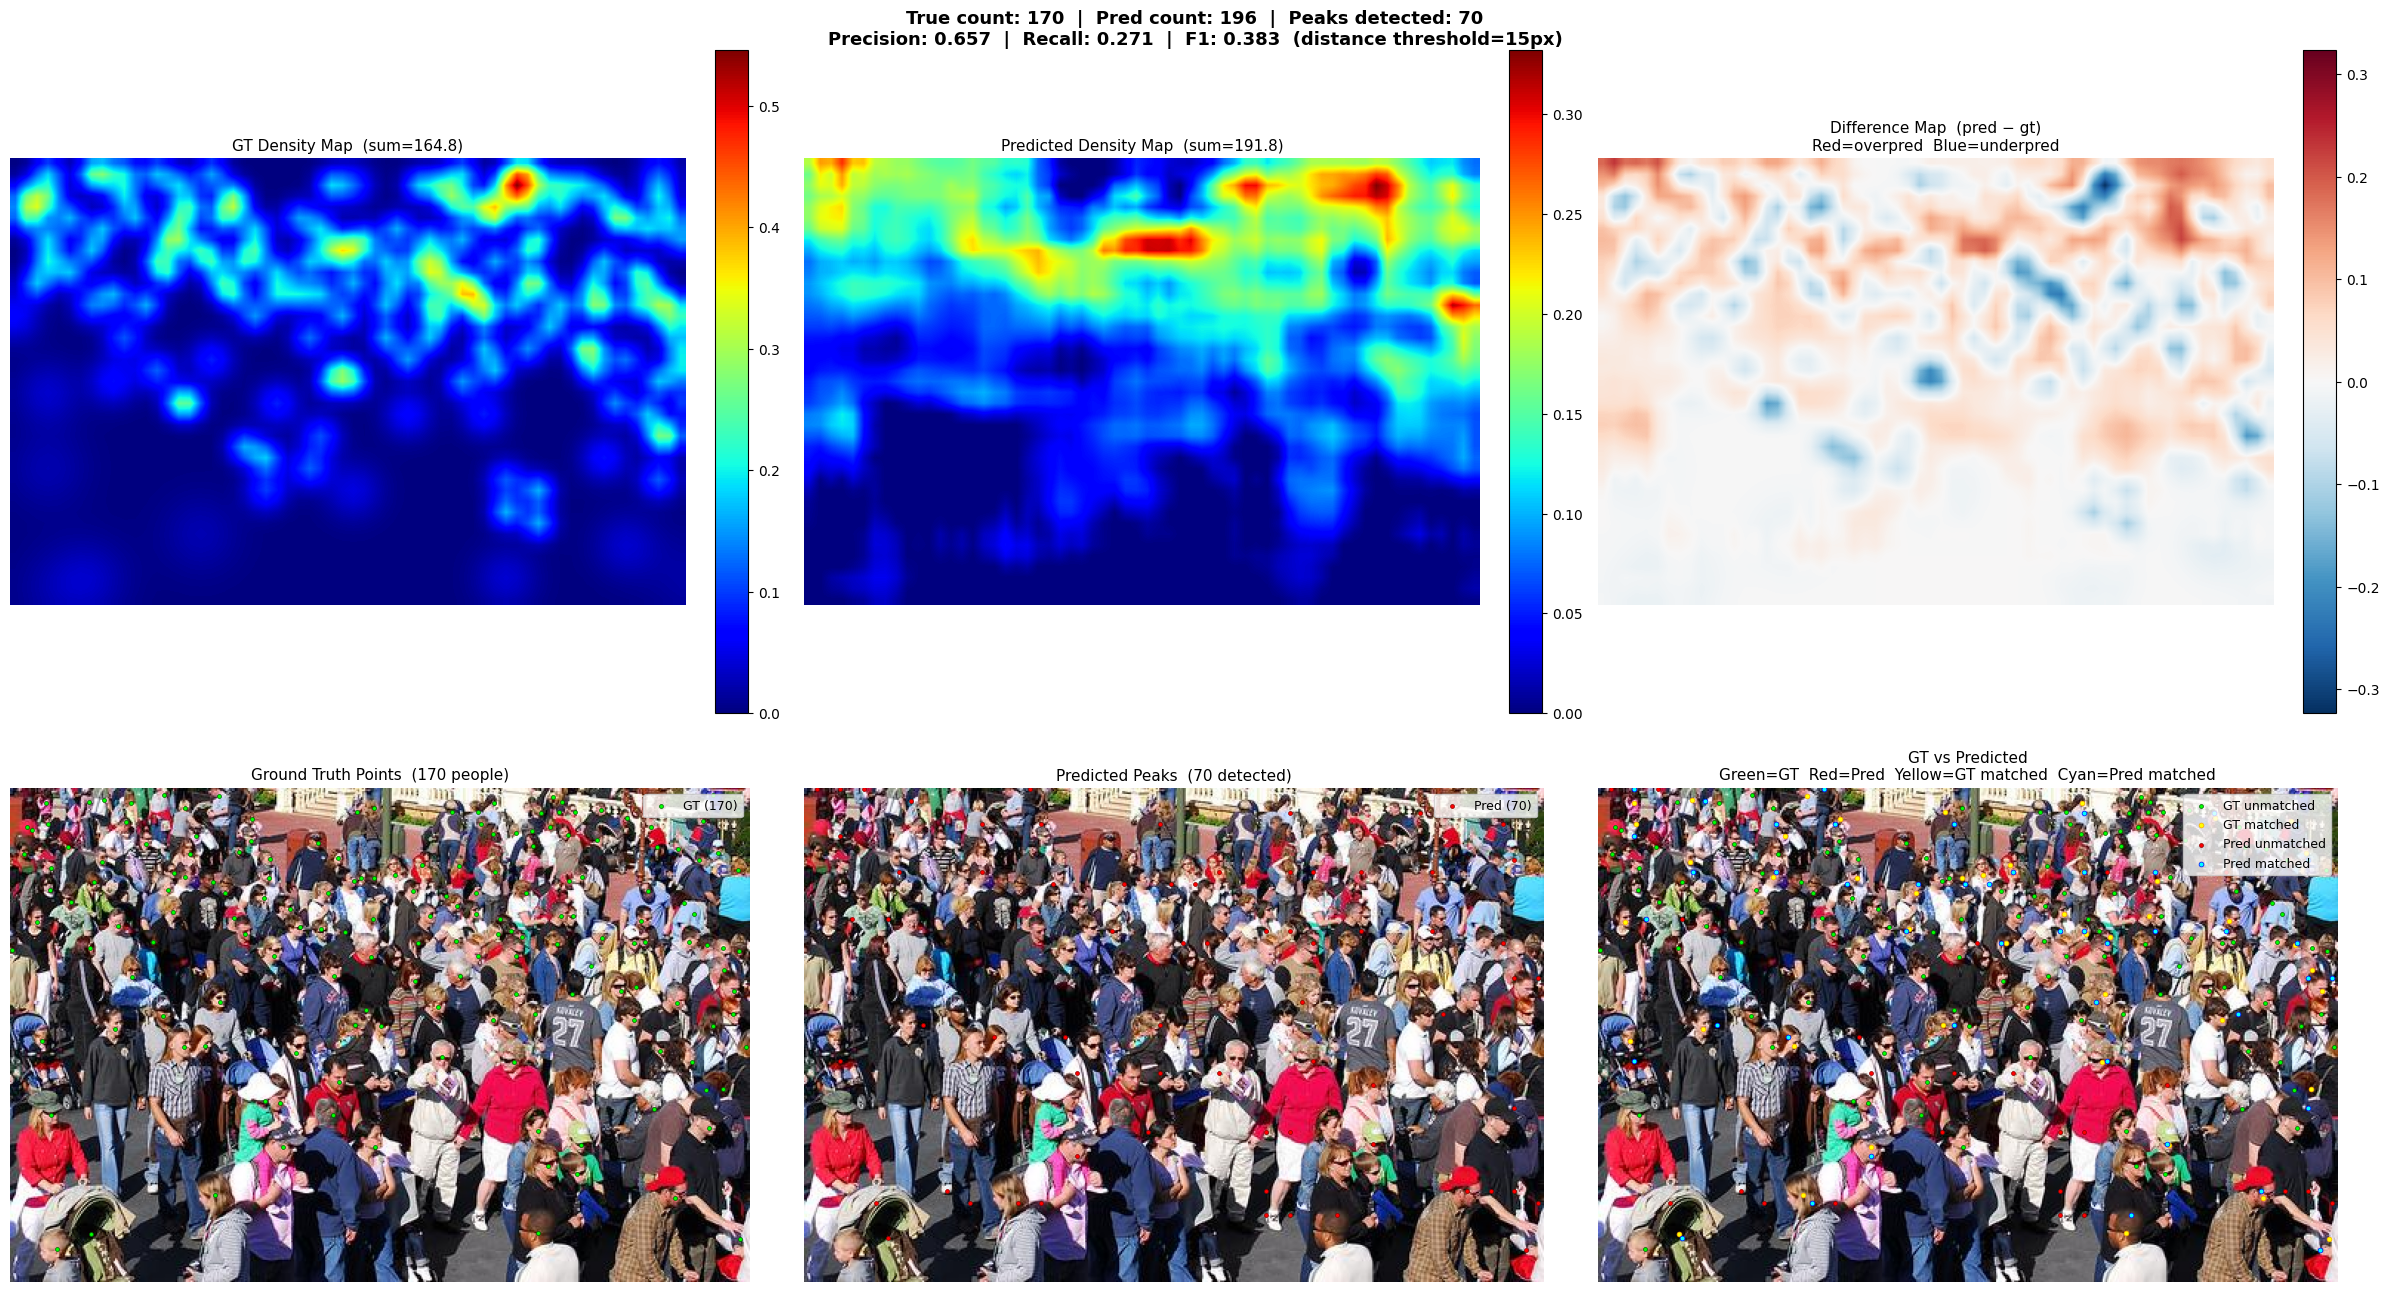


Saved to /content/inference_result.png


In [18]:
from scipy.ndimage import maximum_filter, label
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── CONFIG ────────────────────────────────────────────────────────────────
TEST_IMAGE_PATH    = '/content/IMG_4.jpg'   # ← change this
TEST_MAT_PATH      = '/content/GT_IMG_4.mat'      # ← change this
DISTANCE_THRESHOLD = 15
# ─────────────────────────────────────────────────────────────────────────

# ── 1. Load best weights ──────────────────────────────────────────────────
model.load_weights('/content/CSRNet.weights.h5')
print('Weights loaded.')

# ── 2. Load and preprocess image ──────────────────────────────────────────
orig_image    = img_to_array(load_img(TEST_IMAGE_PATH)).astype(np.float32)
ORIG_H, ORIG_W = orig_image.shape[:2]

im_array = orig_image.copy()
im_array /= 255.0
im_array[:,:,0] = (im_array[:,:,0] - np.mean(im_array[:,:,0])) / np.std(im_array[:,:,0])
im_array[:,:,1] = (im_array[:,:,1] - np.mean(im_array[:,:,1])) / np.std(im_array[:,:,1])
im_array[:,:,2] = (im_array[:,:,2] - np.mean(im_array[:,:,2])) / np.std(im_array[:,:,2])

padded_img     = pad_to_multiple(im_array, factor=32)
PAD_H, PAD_W   = padded_img.shape[:2]

# ── 3. Load ground truth points ───────────────────────────────────────────
mat        = scipy.io.loadmat(TEST_MAT_PATH)
gt_points  = mat['image_info'][0][0][0][0][0].copy()  # (N,2) x,y in image space
true_count = len(gt_points)

# ── 4. Generate GT density map (adaptive kernel, same as training) ────────
scaled_points  = gt_points.copy() / SUBSAMPLING_FACTOR
gt_density_map = get_density_map_gaussian(
    padded_img, scaled_points,
    subsampling_factor=SUBSAMPLING_FACTOR,
    gaussian_radius=5
)

# ── 5. Predict density map ────────────────────────────────────────────────
X_tensor    = tf.constant(np.expand_dims(padded_img, axis=0), dtype=tf.float32)
y_pred      = model(X_tensor, training=False)
pred_density_map = y_pred[0].numpy()  # (H/8, W/8)
pred_count  = float(np.sum(pred_density_map))

# Crop both density maps to original image size (remove padding region)
CROP_H = ORIG_H // SUBSAMPLING_FACTOR
CROP_W = ORIG_W // SUBSAMPLING_FACTOR
gt_density_map_crop   = gt_density_map[:CROP_H, :CROP_W]
pred_density_map_crop = pred_density_map[:CROP_H, :CROP_W]

print(f'\nTrue count  : {true_count}')
print(f'Pred count  : {pred_count:.1f}')
print(f'Count error : {abs(pred_count - true_count):.1f}')

# ── 6. Extract predicted points from density map via peak detection ───────
def density_map_to_points(density_map, subsampling_factor=8,
                           min_distance=3, threshold_rel=0.01):
    threshold = threshold_rel * density_map.max()
    binary    = density_map > threshold
    local_max = maximum_filter(density_map, size=max(3, min_distance)) == density_map
    local_max = local_max & binary

    labeled, num_features = label(local_max)
    pred_points = []
    for region_id in range(1, num_features + 1):
        region_pixels = np.argwhere(labeled == region_id)
        centroid      = region_pixels.mean(axis=0)
        x_orig        = centroid[1] * subsampling_factor
        y_orig        = centroid[0] * subsampling_factor
        pred_points.append([x_orig, y_orig])

    return np.array(pred_points) if pred_points else np.zeros((0, 2))

pred_points = density_map_to_points(pred_density_map, subsampling_factor=SUBSAMPLING_FACTOR)
print(f'Peaks detected : {len(pred_points)}')

# ── 7. Localization metrics ───────────────────────────────────────────────
def compute_localization_metrics(gt_points, pred_points, threshold=15):
    if len(pred_points) == 0 or len(gt_points) == 0:
        return 0.0, 0.0, 0.0, []

    gt_tree            = KDTree(gt_points)
    distances, indices = gt_tree.query(pred_points, k=1)

    matched_gt     = set()
    true_positives = 0
    tp_pairs       = []

    for i, (dist, gt_idx) in enumerate(zip(distances, indices)):
        if dist <= threshold and gt_idx not in matched_gt:
            true_positives += 1
            matched_gt.add(gt_idx)
            tp_pairs.append((pred_points[i], gt_points[gt_idx]))

    precision = true_positives / len(pred_points) if len(pred_points) > 0 else 0.0
    recall    = true_positives / len(gt_points)   if len(gt_points)   > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    return precision, recall, f1, tp_pairs

precision, recall, f1, tp_pairs = compute_localization_metrics(
    gt_points, pred_points, threshold=DISTANCE_THRESHOLD
)

print(f'\n── Localization Metrics (threshold={DISTANCE_THRESHOLD}px) ──')
print(f'  Precision : {precision:.3f}  ({int(precision*len(pred_points))}/{len(pred_points)} predicted correct)')
print(f'  Recall    : {recall:.3f}  ({int(recall*len(gt_points))}/{len(gt_points)} GT found)')
print(f'  F1 Score  : {f1:.3f}')

# ── 8. Visualisation — 5 images in 2 rows ────────────────────────────────
display_img = np.clip(orig_image, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle(
    f'True count: {true_count}  |  Pred count: {pred_count:.0f}  |  '
    f'Peaks detected: {len(pred_points)}\n'
    f'Precision: {precision:.3f}  |  Recall: {recall:.3f}  |  F1: {f1:.3f}  '
    f'(distance threshold={DISTANCE_THRESHOLD}px)',
    fontsize=13, fontweight='bold'
)

# ── Row 1, Col 1: GT density map ──────────────────────────────────────────
im0 = axes[0, 0].imshow(gt_density_map_crop, cmap='jet', interpolation='bilinear')
axes[0, 0].set_title(f'GT Density Map  (sum={np.sum(gt_density_map_crop):.1f})', fontsize=11)
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)
axes[0, 0].axis('off')

# ── Row 1, Col 2: Predicted density map ──────────────────────────────────
im1 = axes[0, 1].imshow(pred_density_map_crop, cmap='jet', interpolation='bilinear')
axes[0, 1].set_title(f'Predicted Density Map  (sum={np.sum(pred_density_map_crop):.1f})', fontsize=11)
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)
axes[0, 1].axis('off')

# ── Row 1, Col 3: Density map difference ─────────────────────────────────
diff_map = pred_density_map_crop - gt_density_map_crop
im2 = axes[0, 2].imshow(diff_map, cmap='RdBu_r', interpolation='bilinear',
                          vmin=-np.abs(diff_map).max(), vmax=np.abs(diff_map).max())
axes[0, 2].set_title('Difference Map  (pred − gt)\nRed=overpred  Blue=underpred', fontsize=11)
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)
axes[0, 2].axis('off')

# ── Row 2, Col 1: GT points on image ─────────────────────────────────────
axes[1, 0].imshow(display_img)
axes[1, 0].set_title(f'Ground Truth Points  ({true_count} people)', fontsize=11)
if len(gt_points) > 0:
    axes[1, 0].scatter(gt_points[:, 0], gt_points[:, 1],
                       c='lime', s=8, linewidths=0.5,
                       edgecolors='darkgreen', label=f'GT ({true_count})')
axes[1, 0].legend(loc='upper right', fontsize=9)
axes[1, 0].axis('off')

# ── Row 2, Col 2: Predicted points on image ───────────────────────────────
axes[1, 1].imshow(display_img)
axes[1, 1].set_title(f'Predicted Peaks  ({len(pred_points)} detected)', fontsize=11)
if len(pred_points) > 0:
    axes[1, 1].scatter(pred_points[:, 0], pred_points[:, 1],
                       c='red', s=8, linewidths=0.5,
                       edgecolors='darkred', label=f'Pred ({len(pred_points)})')
axes[1, 1].legend(loc='upper right', fontsize=9)
axes[1, 1].axis('off')

# ── Row 2, Col 3: Both overlaid ───────────────────────────────────────────
axes[1, 2].imshow(display_img)
axes[1, 2].set_title('GT vs Predicted\nGreen=GT  Red=Pred  Yellow=GT matched  Cyan=Pred matched',
                      fontsize=11)

matched_gt_pts   = np.array([p[1] for p in tp_pairs]) if tp_pairs else np.zeros((0, 2))
matched_pred_pts = np.array([p[0] for p in tp_pairs]) if tp_pairs else np.zeros((0, 2))
matched_gt_set   = set(map(tuple, matched_gt_pts.tolist()))
matched_pred_set = set(map(tuple, matched_pred_pts.tolist()))

if len(gt_points) > 0:
    unmatched_gt = np.array([p for p in gt_points.tolist()
                              if tuple(p) not in matched_gt_set])
    if len(unmatched_gt) > 0:
        axes[1, 2].scatter(unmatched_gt[:, 0], unmatched_gt[:, 1],
                           c='lime', s=8, edgecolors='darkgreen',
                           linewidths=0.5, label='GT unmatched')
    if len(matched_gt_pts) > 0:
        axes[1, 2].scatter(matched_gt_pts[:, 0], matched_gt_pts[:, 1],
                           c='yellow', s=12, edgecolors='orange',
                           linewidths=0.5, label='GT matched')

if len(pred_points) > 0:
    unmatched_pred = np.array([p for p in pred_points.tolist()
                                if tuple(p) not in matched_pred_set])
    if len(unmatched_pred) > 0:
        axes[1, 2].scatter(unmatched_pred[:, 0], unmatched_pred[:, 1],
                           c='red', s=8, edgecolors='darkred',
                           linewidths=0.5, label='Pred unmatched')
    if len(matched_pred_pts) > 0:
        axes[1, 2].scatter(matched_pred_pts[:, 0], matched_pred_pts[:, 1],
                           c='cyan', s=12, edgecolors='blue',
                           linewidths=0.5, label='Pred matched')

axes[1, 2].legend(loc='upper right', fontsize=9)
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('/content/inference_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved to /content/inference_result.png')